In [2]:
import pandas as pd
import numpy as np
import re
import string
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Setup complete.")

Setup complete.


In [3]:
true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")

print("True.csv shape:", true_df.shape)
print("Fake.csv shape:", fake_df.shape)
print("\nColumns:", true_df.columns.tolist())
true_df["label"] = 1
fake_df["label"] = 0

data = pd.concat([true_df, fake_df], axis=0, ignore_index=True)
data = data.dropna(subset=["title", "text"])
data = data.drop_duplicates(subset=["text"])
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nCombined dataset shape:", data.shape)
print("\nClass balance:\n", data["label"].value_counts())
data.head()

True.csv shape: (21417, 4)
Fake.csv shape: (23481, 4)

Columns: ['title', 'text', 'subject', 'date']

Combined dataset shape: (38646, 5)

Class balance:
 label
1    21192
0    17454
Name: count, dtype: int64


,title,text,subject,date,label
0,TOP 10 TWEETS From Democrat Debate,"Here s the fake black guy, Shaun King weighing...",politics,"Oct 14, 2015",0
1,Incredible Photo Of North Korean Soldier Secr...,While Trump s Secretary of State was visiting ...,News,"March 17, 2017",0
2,Patrick Henningsen LIVE with guest Sean Stone ...,Join Patrick every week here at 21WIRE.TV for ...,US_News,"December 8, 2016",0
3,Trump Just Bragged About The Size Of His Hand...,The size of Donald Trump s hands seems to be a...,News,"September 14, 2017",0
4,Trump asks for probe into imports of foreign-m...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 20, 2017",1


In [4]:
def remove_reuters_tag(text):
    return re.sub(r'^.*?\(Reuters\)\s*-\s*', '', text)

data["text"] = data["text"].apply(remove_reuters_tag)

print("Sample after Reuters-tag removal:\n")
print(data.loc[data["label"] == 1, "text"].iloc[0][:300])

Sample after Reuters-tag removal:

U.S. President Donald Trump on Thursday will sign a directive asking for a speedy probe into whether imports of foreign-made steel are hurting U.S. national security, two administration officials said on Wednesday. Trump is to sign the memorandum related to section 232 of the Trade Expansion Act of 


In [5]:
STOPWORDS = set("""
a about above after again against all am an and any are aren't as at be because been before being below between both but by can't cannot could
couldn't did didn't do does doesn't doing don't down during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's
her here here's hers herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most mustn't my myself
no nor not of off on once only or other ought our ours ourselves out over own same shan't she she'd she'll she's should shouldn't so some such than
that that's the their theirs them themselves then there there's these they they'd they'll they're they've this those through to too under until up
very was wasn't we we'd we'll we're we've were weren't what what's when when's where where's which while who who's whom why why's with won't would
wouldn't you you'd you'll you're you've your yours yourself yourselves """.split())

def clean_text(text):
    """Lowercase, strip URLs/HTML, remove punctuation & digits."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)          
    text = re.sub(r'<.*?>', ' ', text)                   
    text = re.sub(r'[^a-z\s]', ' ', text)               
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

def manual_tokenize(text):
    """Simple whitespace tokenizer (manual, no nltk)."""
    return text.split()

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

def preprocess(text):
    text = clean_text(text)
    tokens = manual_tokenize(text)
    tokens = remove_stopwords(tokens)
    return " ".join(tokens)

print("Cleaning text...")
t0 = time.time()
data["full_text"] = data["title"] + " " + data["text"]
data["clean_text"] = data["full_text"].apply(preprocess)
print(f"Done in {time.time() - t0:.1f}s")

data[["clean_text", "label"]].head()

Cleaning text...
Done in 9.2s


,clean_text,label
0,top tweets democrat debate fake black guy shau...,0
1,incredible photo north korean soldier secretly...,0
2,patrick henningsen live guest sean stone proje...,0
3,trump just bragged size hands hurricane irma r...,0
4,trump asks probe imports foreign made steel of...,1


In [7]:
print("DATA QUALITY ASSESSMENT")
print(f"Total rows: {len(data)}")
print(f"Duplicate rows: {data.duplicated().sum()}")

print("\nMissing Values:")
print(data.isnull().sum())

print("\nData Types:")
print(data.dtypes)

DATA QUALITY ASSESSMENT
Total rows: 38646
Duplicate rows: 0

Missing Values:
title         0
text          0
subject       0
date          0
label         0
full_text     0
clean_text    0
dtype: int64

Data Types:
title         object
text          object
subject       object
date          object
label          int64
full_text     object
clean_text    object
dtype: object


C:\Users\snigd\AppData\Local\Temp\ipykernel_2504\4049598487.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=data, palette=["#E74C3C", "#2ECC71"])


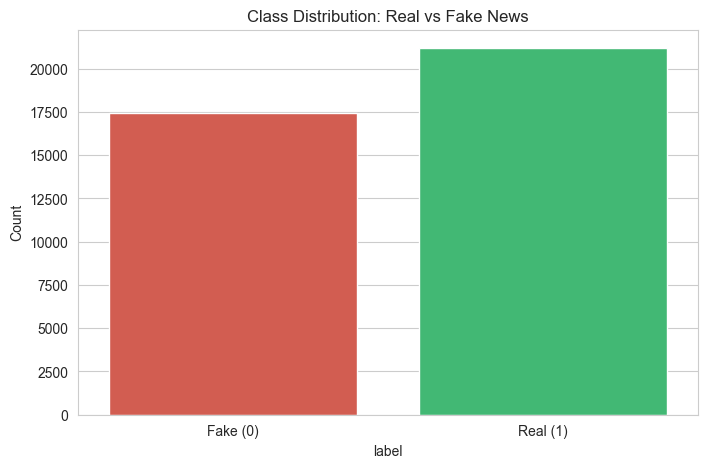

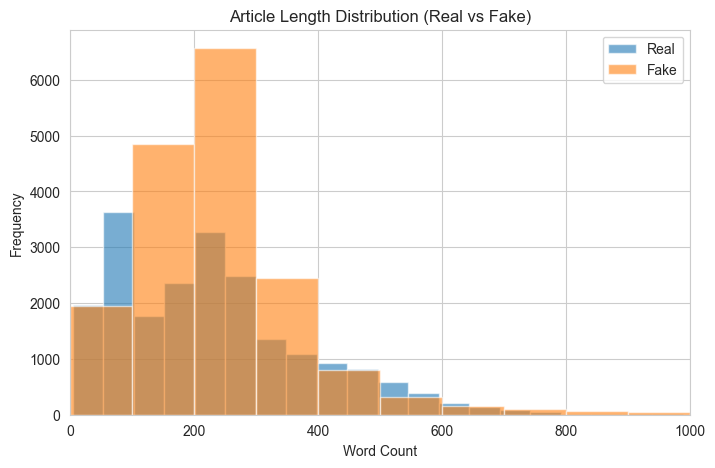

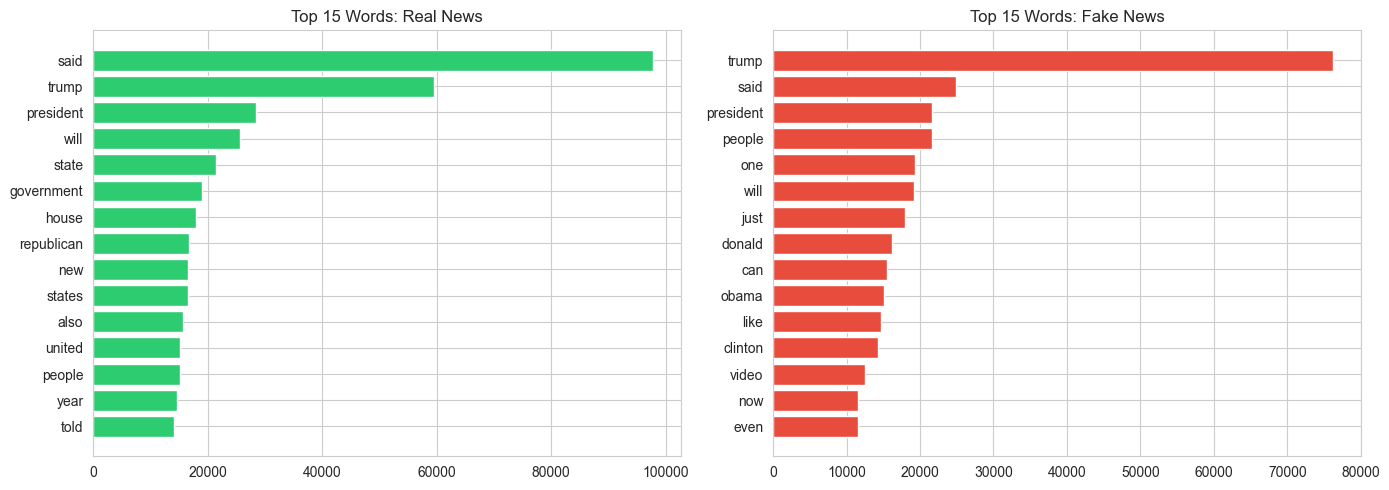

In [8]:
plt.figure()
sns.countplot(x="label", data=data, palette=["#E74C3C", "#2ECC71"])
plt.xticks([0, 1], ["Fake (0)", "Real (1)"])
plt.title("Class Distribution: Real vs Fake News")
plt.ylabel("Count")
plt.savefig("eda_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

data["word_count"] = data["clean_text"].apply(lambda x: len(x.split()))

plt.figure()
plt.hist(data.loc[data.label == 1, "word_count"], bins=50, alpha=0.6, label="Real")
plt.hist(data.loc[data.label == 0, "word_count"], bins=50, alpha=0.6, label="Fake")
plt.xlim(0, 1000)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Article Length Distribution (Real vs Fake)")
plt.legend()
plt.savefig("eda_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

from collections import Counter

def top_words(label_value, n=15):
    all_tokens = " ".join(data.loc[data.label == label_value, "clean_text"]).split()
    return Counter(all_tokens).most_common(n)

real_top = top_words(1)
fake_top = top_words(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([w for w, c in real_top][::-1], [c for w, c in real_top][::-1], color="#2ECC71")
axes[0].set_title("Top 15 Words: Real News")
axes[1].barh([w for w, c in fake_top][::-1], [c for w, c in fake_top][::-1], color="#E74C3C")
axes[1].set_title("Top 15 Words: Fake News")
plt.tight_layout()
plt.savefig("eda_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
def compute_tf(tokens):
    """Term frequency for one document."""
    tf = Counter(tokens)
    total = len(tokens)
    return {word: count / total for word, count in tf.items()} if total > 0 else {}

def compute_idf(tokenized_docs):
    """Inverse document frequency across the corpus."""
    n_docs = len(tokenized_docs)
    df = Counter()
    for tokens in tokenized_docs:
        for word in set(tokens):
            df[word] += 1
    return {word: np.log(n_docs / (1 + count)) + 1 for word, count in df.items()}

def compute_tfidf_manual(tokenized_docs):
    """Returns list of {word: tfidf_score} dicts, one per document."""
    idf = compute_idf(tokenized_docs)
    tfidf_docs = []
    for tokens in tokenized_docs:
        tf = compute_tf(tokens)
        tfidf_docs.append({word: tf_val * idf.get(word, 0) for word, tf_val in tf.items()})
    return tfidf_docs, idf

sample_docs = data["clean_text"].iloc[:5].apply(manual_tokenize).tolist()
manual_scores, _ = compute_tfidf_manual(sample_docs)

print("Manual TF-IDF for document 0 (top 5 terms):")
top5 = sorted(manual_scores[0].items(), key=lambda x: -x[1])[:5]
for word, score in top5:
    print(f"  {word}: {score:.4f}")

Manual TF-IDF for document 0 (top 5 terms):
  october: 0.0645
  debate: 0.0581
  shaun: 0.0276
  tweet: 0.0276
  race: 0.0276


In [10]:
X_text = data["clean_text"]
y = data["label"]

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(X_text)
print("Bag-of-Words shape:", X_bow.shape)

tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(X_text)
print("TF-IDF shape:", X_tfidf.shape)

Bag-of-Words shape: (38646, 5000)
TF-IDF shape: (38646, 5000)


In [11]:
from gensim.models import Word2Vec
import numpy as np
sentences = [text.split() for text in data["clean_text"]]
word2vec_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)
print("Vocabulary Size:", len(word2vec_model.wv))
example_word = "government"
if example_word in word2vec_model.wv:
    print("\nEmbedding vector (first 10 values):")
    print(word2vec_model.wv[example_word][:10])

Vocabulary Size: 66164

Embedding vector (first 10 values):
[-0.18721628 -0.2111849   2.0494409  -0.9105513   3.3191998  -3.2616007
 -1.8671433   2.1730506   0.828864    2.3035183 ]


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (30916, 5000)
Test shape: (7730, 5000)


In [15]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "LogReg": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=RANDOM_STATE)
}
trained_models = {}
training_times = {}

for name, model in models.items():
    print(f"Training {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    training_times[name] = time.time() - t0
    trained_models[name] = model
    print(f"  Done in {training_times[name]:.1f}s")

Training KNN...
  Done in 0.0s
Training LogReg...
  Done in 0.3s
Training RandomForest...
  Done in 6.0s
Training NeuralNet...
  Done in 116.7s


In [16]:
results = []

for name, model in trained_models.items():
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Train Time (s)": training_times[name]
    })

    print(f"\n{name}\n")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds, target_names=["Fake", "Real"]))

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df.to_csv("model_results.csv", index=False)
print("\nResults saved to model_results.csv")
results_df


KNN

Accuracy:  0.6846
Precision: 0.9395
Recall:    0.4541
F1-Score:  0.6123

Classification Report:
              precision    recall  f1-score   support

        Fake       0.59      0.96      0.73      3491
        Real       0.94      0.45      0.61      4239

    accuracy                           0.68      7730
   macro avg       0.77      0.71      0.67      7730
weighted avg       0.78      0.68      0.67      7730


LogReg

Accuracy:  0.9840
Precision: 0.9813
Recall:    0.9896
F1-Score:  0.9854

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      3491
        Real       0.98      0.99      0.99      4239

    accuracy                           0.98      7730
   macro avg       0.98      0.98      0.98      7730
weighted avg       0.98      0.98      0.98      7730


RandomForest

Accuracy:  0.9849
Precision: 0.9815
Recall:    0.9910
F1-Score:  0.9863

Classification Report:
              precision    r

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
3,NeuralNet,0.988875,0.990782,0.988912,0.989847,116.695004
2,RandomForest,0.984864,0.981542,0.991036,0.986266,5.963027
1,LogReg,0.983959,0.981287,0.989620,0.985436,0.262724
0,KNN,0.684605,0.939483,0.454117,0.612277,0.021452


In [17]:
display(results_df.sort_values("Accuracy", ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
3,NeuralNet,0.988875,0.990782,0.988912,0.989847,116.695004
2,RandomForest,0.984864,0.981542,0.991036,0.986266,5.963027
1,LogReg,0.983959,0.981287,0.989620,0.985436,0.262724
0,KNN,0.684605,0.939483,0.454117,0.612277,0.021452


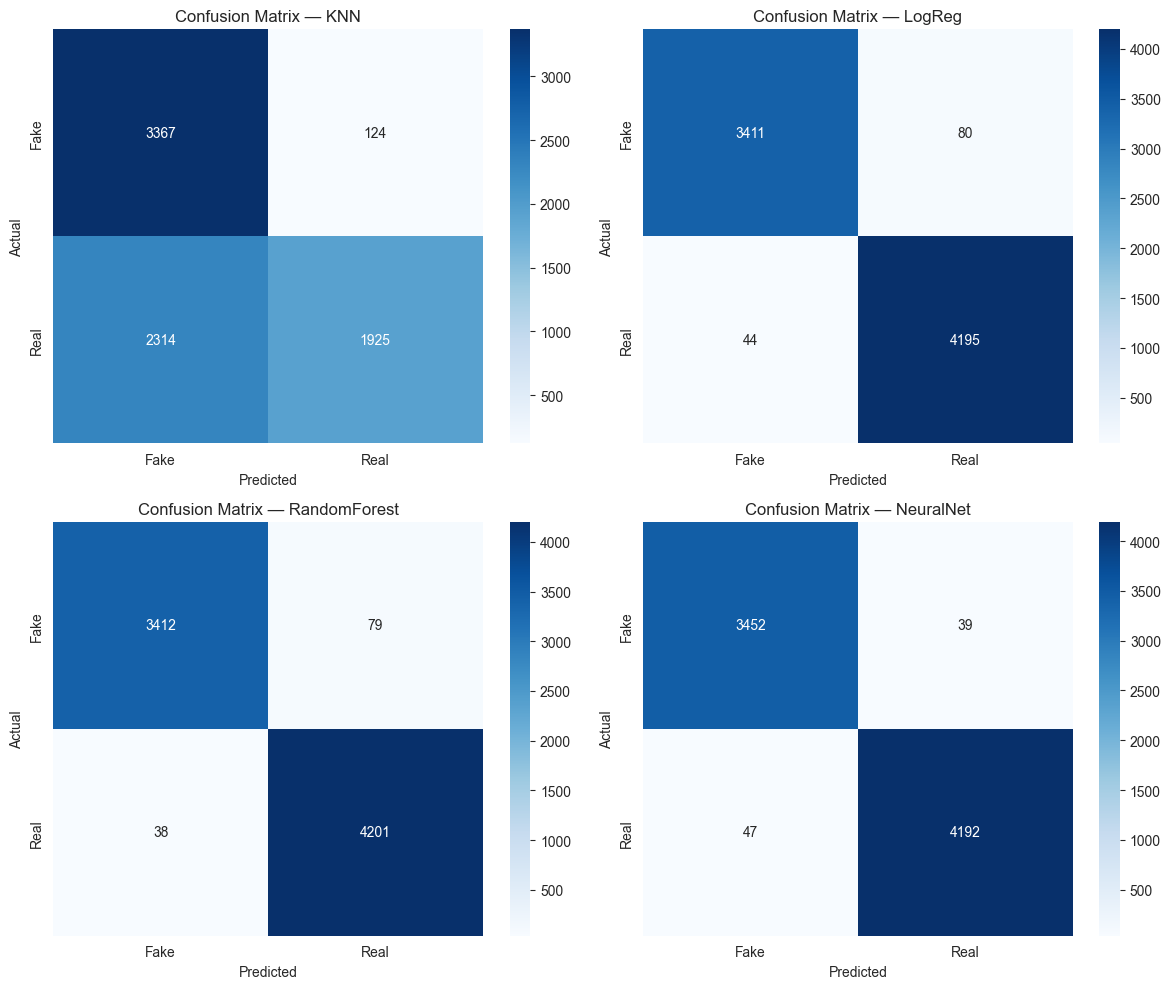

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained_models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
best_model = results_df.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]
print("BEST PERFORMING MODEL")
print(best_model)

BEST PERFORMING MODEL
Model              NeuralNet
Accuracy            0.988875
Precision           0.990782
Recall              0.988912
F1-Score            0.989847
Train Time (s)    116.695004
Name: 3, dtype: object


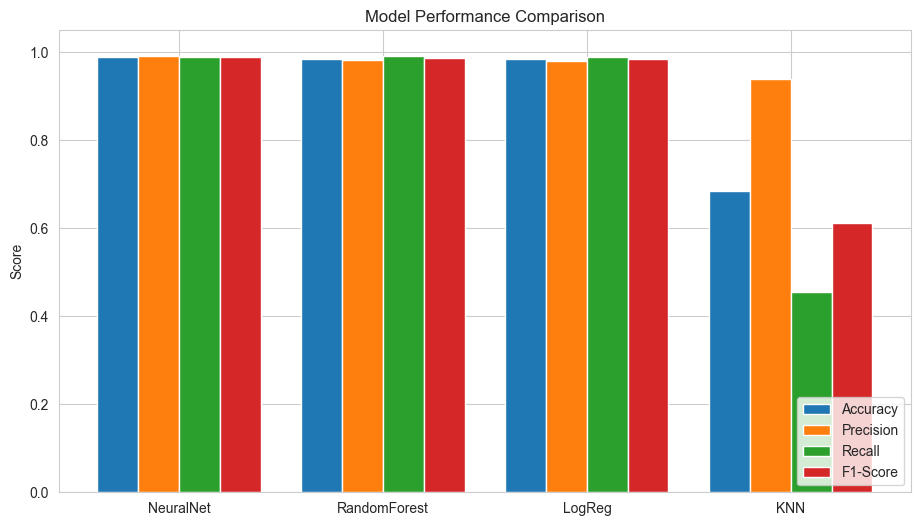

Parametric models:     Logistic Regression, Neural Network
Non-parametric models: KNN, Random Forest


In [14]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend(loc="lower right")
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Parametric models:     Logistic Regression, Neural Network")
print("Non-parametric models: KNN, Random Forest")

In [19]:
comparison = pd.DataFrame({
    "Category":[
        "Parametric",
        "Parametric",
        "Non-Parametric",
        "Non-Parametric"
    ],

    "Model":[
        "Logistic Regression",
        "Neural Network",
        "KNN",
        "Random Forest"
    ]
})
display(comparison)

,Category,Model
0,Parametric,Logistic Regression
1,Parametric,Neural Network
2,Non-Parametric,KNN
3,Non-Parametric,Random Forest


In [15]:
test_sample = data.loc[y_test.index, ["title", "label"]].copy()
test_sample["predicted_LogReg"] = trained_models["LogReg"].predict(X_test)
test_sample = test_sample.sample(20, random_state=RANDOM_STATE)
test_sample.to_csv("test_data_samples.csv", index=False)
print("Saved 20 test samples to test_data_samples.csv")
test_sample.head(10)

Saved 20 test samples to test_data_samples.csv


,title,label,predicted_LogReg
35780,Father of Philippine Islamist militant leaders...,1,1
3201,Canadian court rules Trump can face claims in ...,1,1
22778,5-Star Mooch and Free-Loading Granny Drop In F...,0,0
30730,Ted Cruz Says Endorsing Trump Is A ‘Grave Mis...,0,0
17524,Texas Lawmaker Files CRUCIAL Bill That Could ...,0,0
25999,Kirkuk shaping up as flashpoint ahead of Kurdi...,1,1
18496,Fox News Shows REAL REACTION From Demoralized...,0,0
23995,Syrian army takes last Islamic State bastion i...,1,1
12353,White House staff exits likely as Trump's firs...,1,1
3597,Donald Trump's Hollywood Walk of Fame star van...,1,0
